In [1]:
from datasets import load_dataset# pip install
import os
import numpy as np #pip install
import matplotlib.pyplot as plt #pip install
import plotly.express as px # pip install plotly
from collections import defaultdict
import pandas as pd # pip install
from shapely.geometry import Point # pip install
import geopandas as gpd # pip install
from geopandas import GeoDataFrame 
import geodatasets # pip install
from scipy.stats import gaussian_kde # pip install
from sklearn.metrics.pairwise import haversine_distances #pip install scikit-learn

d:\school_mapje\msc\mmeb\project\.venv_cryptic_bio\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#env variables
out_dir = 'output/'

#create out folder
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

#### load dataset + base stastics

In [3]:
# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("gmanolache/CrypticBio")
common =load_dataset("gmanolache/CrypticBio", data_files="CrypticBio-Benchmark/CrypticBio-Common.csv", split="train")
print(common.features)

Generating train split:   0%|                                                                                                                                       | 0/171832985 [00:00<?, ? examples/s]

Generating train split:   0%|▏                                                                                                                    | 287286/171832985 [00:00<01:50, 1557101.84 examples/s]

Generating train split:   0%|▍                                                                                                                    | 573838/171832985 [00:00<01:48, 1573959.58 examples/s]

Generating train split:   1%|▌                                                                                                                    | 859552/171832985 [00:00<01:49, 1563195.73 examples/s]

Generating train split:   1%|▊                                                                                                                   | 1185907/171832985 [00:00<01:51, 1536520.42 examples/s]

...

Generating train split: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171832985/171832985 [03:20<00:00, 1206778.18 examples/s]

Generating train split: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171832985/171832985 [03:20<00:00, 856316.44 examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 15801 examples [00:00, 172761.37 examples/s]

{'scientificName': Value('large_string'), 'year': Value('float64'), 'month': Value('float64'), 'day': Value('float64'), 'decimalLatitude': Value('float64'), 'decimalLongitude': Value('float64'), 'url': Value('large_string'), 'kingdom': Value('large_string'), 'phylum': Value('large_string'), 'class': Value('large_string'), 'order': Value('large_string'), 'family': Value('large_string'), 'genus': Value('large_string'), 'vernacularName': Value('large_string')}


In [4]:
for i in range(len(common)):
    if common[i]['month'] == None:
        print('month none')
    if common[i]['day'] == None:
        print('day none')
    if common[i]['decimalLatitude'] == None:
        print('decimalLatitude none')
        print(common[i]['scientificName'])
    if common[i]['decimalLongitude'] == None:
        print('decimalLongitude none')
    if common[i]['scientificName'] == None:
        print('scientificName none')

decimalLatitude none
Scytodes thoracica
decimalLongitude none


decimalLatitude none


Zygiella x-notata
decimalLongitude none
decimalLatitude none
Oecobius navus
decimalLongitude none
decimalLatitude none
Araneus pegnia
decimalLongitude none


In [5]:
#all names from each level

levels = {'kingdom': {},
          'phylum': {},
          'class': {},
          'order': {},
          'family': {},
          'genus': {},
          'scientificName': {}
          }



for i in range(len(common)):
    for level in levels.keys(): 
        if common[i][level] not in levels[level].keys():
            levels[level][common[i][level]] = 1
        else:
            levels[level][common[i][level]] += 1




In [6]:
print(levels)
print(sum(levels['kingdom'].values()))
print(len(levels['scientificName'].keys()))
print(set(levels['scientificName'].values()))

print(levels['class'].values())




{'kingdom': {'Animalia': 11201, 'Fungi': 2300, 'Plantae': 2300}, 'phylum': {'Arthropoda': 4500, 'Basidiomycota': 2300, 'Mollusca': 2401, 'Chordata': 4300, 'Tracheophyta': 2300}, 'class': {'Arachnida': 2200, 'Agaricomycetes': 2300, 'Insecta': 2300, 'Gastropoda': 2401, 'Aves': 2500, 'Magnoliopsida': 2300, 'Squamata': 1800}, 'order': {'Araneae': 2200, 'Agaricales': 2200, 'Russulales': 100, 'Coleoptera': 2300, 'Stylommatophora': 2301, 'Cycloneritida': 100, 'Passeriformes': 2500, 'Asterales': 2000, 'Fabales': 200, 'Caryophyllales': 100, None: 1800}, 'family': {'Theridiidae': 800, 'Uloboridae': 100, 'Araneidae': 800, 'Scytodidae': 100, 'Pholcidae': 200, 'Mimetidae': 100, 'Oecobiidae': 100, 'Amanitaceae': 2100, 'Russulaceae': 100, 'Strophariaceae': 100, 'Coccinellidae': 2300, 'Helicidae': 1100, 'Hygromiidae': 200, 'Geomitridae': 200, 'Achatinidae': 201, 'Xanthonychidae': 300, 'Camaenidae': 200, 'Zachrysiidae': 100, 'Helicinidae': 100, 'Passeridae': 600, 'Paridae': 200, 'Fringillidae': 200, 'P

In [7]:
taxa_dict = defaultdict(int)
for i in range(len(common)):
    tax_name = str()
    for level in levels.keys():
        tax_name += '\t' + str(common[i][level])
    taxa_dict[tax_name] += 1
print(taxa_dict)

defaultdict(<class 'int'>, {'\tAnimalia\tArthropoda\tArachnida\tAraneae\tTheridiidae\tLatrodectus\tLatrodectus geometricus': 100, '\tAnimalia\tArthropoda\tArachnida\tAraneae\tTheridiidae\tSteatoda\tSteatoda grossa': 100, '\tAnimalia\tArthropoda\tArachnida\tAraneae\tUloboridae\tZosis\tZosis geniculata': 100, '\tAnimalia\tArthropoda\tArachnida\tAraneae\tAraneidae\tAraneus\tAraneus diadematus': 100, '\tAnimalia\tArthropoda\tArachnida\tAraneae\tAraneidae\tNephilingis\tNephilingis cruentata': 100, '\tAnimalia\tArthropoda\tArachnida\tAraneae\tAraneidae\tArgiope\tArgiope aurantia': 100, '\tAnimalia\tArthropoda\tArachnida\tAraneae\tScytodidae\tScytodes\tScytodes thoracica': 100, '\tAnimalia\tArthropoda\tArachnida\tAraneae\tAraneidae\tNeoscona\tNeoscona crucifera': 100, '\tAnimalia\tArthropoda\tArachnida\tAraneae\tTheridiidae\tSteatoda\tSteatoda nobilis': 100, '\tAnimalia\tArthropoda\tArachnida\tAraneae\tPholcidae\tHolocnemus\tHolocnemus pluchei': 100, '\tAnimalia\tArthropoda\tArachnida\tAranea

#### taxonomy statistics

In [8]:
rows = []

for path, count in taxa_dict.items():
    parts = path.strip().split("\t")
    rows.append(parts + [count])
df = pd.DataFrame(rows, columns=['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'scientificName', 'count'])

#print(df)

fig = px.treemap(
    df,
    path=levels.keys(),
    values="count",
    color="kingdom"
)

fig.show()

#### Time statistics

In [9]:
year_dict = defaultdict(int)
for i in range(len(common)):
    year_dict[int(common[i]['year'])] += 1

# sort by year
df = pd.DataFrame(
    sorted(year_dict.items()),
    columns=["Year", "Count"]
)

fig = px.bar(
    df,
    x="Year",
    y="Count",
    title="Counts per year (only years with datapoints are shown)"
)

fig.update_layout(xaxis=dict(type="category"))
fig.show()


In [10]:
date_dict = defaultdict(int)
for i in range(len(common)):
    date = int(common[i]['month'])
    date_dict[date] += 1

# sort by date
df = pd.DataFrame(
    sorted(date_dict.items()),
    columns=["Month", "Count"]
)

fig = px.bar(
    df,
    x="Month",
    y="Count",
    title="Counts per Month "
)

fig.update_layout(xaxis=dict(type="category"))
fig.show()

In [11]:
date_dict = defaultdict(int)
for i in range(len(common)):
    date = (int(common[i]['month']), int(common[i]['day']))
    date_dict[date] += 1

# sort by date
rows = []
for (month, day), count in sorted(date_dict.items()):
    date_str = f"{month}-{day}"
    rows.append([date_str, count])

df = pd.DataFrame(rows, columns=["date", "Count"])

fig = px.bar(
    df,
    x="date",
    y="Count",
    title="Counts per date"
)

fig.update_layout(xaxis=dict(type="category"))
fig.show()

In [12]:
#dates by cryptic gorup
date_dict = defaultdict(int)
for i in range(len(common)):
    date = int(common[i]['month'])
    species = common[i]['class']
    date_dict[(date, species)] += 1


# sort by date
rows = [(month, species, count) for (month, species), count in sorted(date_dict.items())]

df = pd.DataFrame(rows, columns=["Month", "Class", "Count"])

fig = px.bar(
    df,
    x="Month",
    y="Count",
    color="Class",
    title="Ratio per month per cryptic group"
)

fig.update_layout(xaxis=dict(type="category"), showlegend=True, barnorm="percent",)
fig.show()


In [13]:
#dates by species heatmap
date_dict = defaultdict(int)
for i in range(len(common)):
    date = int(common[i]['month'])
    clas = common[i]['class']
    species = common[i]['scientificName']
    date_dict[(date, clas, species)] += 1

rows = [(month, clas, species, count) for (month, clas, species), count in date_dict.items()]

df = pd.DataFrame(rows, columns=["Month", "Class", "Species", "Count"])
df = df.sort_values(by=["Class", "Species", "Month"])
species_sort = df[["Class", "Species"]].drop_duplicates().sort_values(by=["Class", "Species"])["Species"]
class_groups = (df[["Class", "Species"]].drop_duplicates().sort_values(by=["Class", "Species"]))
class_order = class_groups["Species"]

df = df.pivot(index="Month", columns="Species", values="Count")
df = df.reindex(columns=class_order)
df = df.sort_index(ascending=True)

fig = px.imshow(
    df,
    labels=dict(y="Month", x="Species", color="Count"),
    aspect="auto",
    title="Month by species heatmap"
)

class_changes = class_groups["Class"].ne(class_groups["Class"].shift())

positions = np.where(class_changes)[0]

for pos in positions[1:]:
    fig.add_vline(x=pos - 0.5, line_width=2, line_color="white")

fig.update_xaxes(showticklabels=False)

#show classes names
class_centers = class_groups.groupby("Class").size().cumsum()
class_starts = class_centers.shift(fill_value=0)

for text, start, end in zip(class_centers.index, class_starts, class_centers):
    fig.add_annotation(
        x=(start + end - 1) / 2,
        y=1.1,
        yref="paper",
        text=text,
        showarrow=False,
    )
fig.show()


In [14]:
# inter/intra species distances(spatial) to file
results, month_offsets = [], np.array([0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334])
date_dict = defaultdict(int)
for i in range(len(common)):
    date = (int(common[i]['month']), int(common[i]['day']), common[i]['scientificName'])
    date_dict[date] += 1

#asummes non-leap year, can be a day of because
rows = []
for (month, day, species), count in date_dict.items():
    rows.append([month, day, species, count])

df = pd.DataFrame(rows, columns=["Month", "Day", "Species", "Count"])
df["date_of_year"] = month_offsets[df["Month"] - 1] + df["Day"]

dates_of_year = df["date_of_year"].values
species_array = df["Species"].values
counts = df["Count"].values
for i in range(len(df)):
    species = species_array[i]
    

    diff = np.abs(dates_of_year[i] - dates_of_year)
    dists = np.minimum(diff, 365 - diff)
    
    # matrix for intra en inter
    intra_mask = (species_array == species)
    inter_mask = (species_array != species)
    intra = dists[intra_mask]
    intra_counted = counts[intra_mask]
    inter = dists[inter_mask]
    inter_counted = counts[inter_mask]

    intra_mean = np.average(intra, weights=intra_counted)
    intra_std = np.sqrt(np.average((intra - intra_mean)**2, weights=intra_counted))
    inter_mean = np.average(inter, weights=inter_counted)
    inter_std = np.sqrt(np.average((inter - inter_mean)**2, weights=inter_counted))
    results.append({
        "species": species,
        "intra_mean": intra_mean,#intra
        "intra_std": intra_std,
        "intra_min": np.min(intra),
        "intra_max": np.max(intra), 
        "inter_mean": inter_mean,#inter
        "inter_std": inter_std,
        "inter_min": np.min(inter),
        "inter_max": np.max(inter)
    })


#by species
species_stats = pd.DataFrame(results).groupby("species").agg({
    "intra_mean": "mean",
    "intra_std": "mean",
    "intra_min": "mean",
    "intra_max": "mean", 
    "inter_mean": "mean",
    "inter_std": "mean",
    "inter_min": "mean",
    "inter_max": "mean"
}).reset_index()

species_stats.to_json(out_dir+"species__time_distance.json", indent=1, orient="records")


In [15]:
# inter/intra species distances(spatial) statistics

print('intra species mean')
print(species_stats.sort_values("intra_mean", ascending=False).tail(10))
print('\ninter species mean')
print(species_stats.sort_values("inter_mean", ascending=False).head(10))
print('\nintra species mean mean')
print(species_stats['intra_mean'].mean())
print('\ninter species mean mean')
print(species_stats['inter_mean'].mean())
print('diference between intra and inter')
print(species_stats['inter_mean'].mean()-species_stats['intra_mean'].mean())

intra species mean
                    species  intra_mean  intra_std  intra_min   intra_max  \
61  Erigeron philadelphicus   39.116765  26.550836        0.0  155.764706   
20        Amanita velatipes   39.078727  25.366380        0.0  103.945455   
4             Amanita basii   34.314483  21.855062        0.0  112.586207   
8         Amanita crenulata   33.364074  22.595624        0.0  115.148148   
11        Amanita frostiana   31.435714  20.312854        0.0   84.946429   
6           Amanita citrina   30.776452  20.034407        0.0  115.290323   
18          Amanita regalis   28.729259  18.234758        0.0   76.240741   
21          Amanita wellsii   27.299091  17.783746        0.0   79.363636   
57        Erigeron coulteri   26.683636  17.231404        0.0   78.309091   
60      Erigeron peregrinus   25.504000  16.223378        0.0   74.780000   

    inter_mean  inter_std  inter_min  inter_max  
61   84.054146  52.128641        0.0      182.0  
20   79.594345  50.603484        

#### location statistics

In [16]:
point_list = []
none_count = 0
for i in range(len(common)):
    lat = common[i]['decimalLatitude']
    lon = common[i]['decimalLongitude']
    
    if lat is None or lon is None:
        none_count += 1
    else:
        point_list.append((lon, lat))

print(f"N of Nones {none_count}")
print(point_list)

N of Nones 4
[(-100.204402, 25.838715), (2.648446, 48.850697), (-43.238047, -22.965164), (-2.077745, 52.516042), (31.390044, -28.364916), (-77.810364, 37.667567), (-69.798498, 44.274268), (10.776795, 45.1827), (-46.730208, -23.564931), (-86.807559, 34.924607), (-117.823023, 33.73282), (-4.064989, 36.727839), (22.914442, 40.891623), (3.913712, 43.565237), (-117.790039, 34.066952), (-122.26979, 47.274756), (-41.794523, -22.397129), (-119.124907, 35.382292), (152.974555, -27.551912), (-83.61503, 41.690035), (-123.108475, 49.343269), (-58.407113, -34.636129), (-71.05682, 42.343465), (-118.199811, 33.987658), (-71.056655, 42.919955), (172.672929, -43.520859), (-97.386862, 28.654581), (-97.758963, 30.45832), (-81.216459, 34.041473), (-77.249705, 38.658172), (-46.63, -23.34), (-9.309032, 38.690165), (4.829354, 45.769892), (12.239622, 53.754915), (145.351438, -37.654128), (0.171388, 48.605022), (-95.158997, 31.392722), (-65.82716, 45.521343), (-95.451355, 29.767205), (-95.682119, 29.812231), (

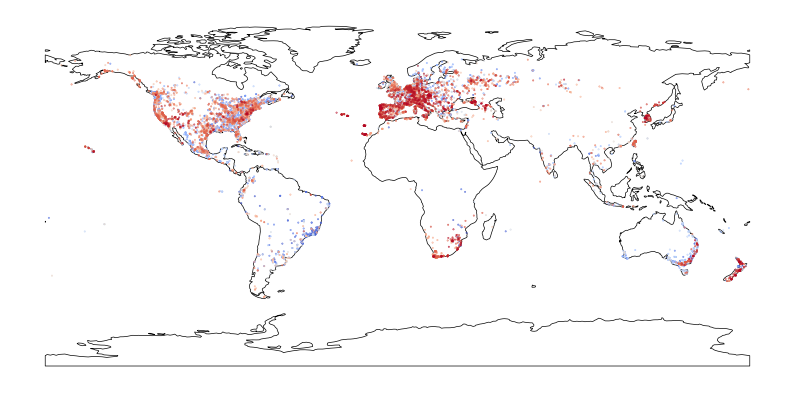

In [17]:
df = pd.DataFrame(point_list, columns=["latitude", "longitude"])

geometry = [Point(xy) for xy in zip(df["latitude"], df["longitude"])]
gdf = GeoDataFrame(point_list, geometry=geometry)   

# calculate density
xy = df[["longitude", "latitude"]].to_numpy().T
density = gaussian_kde(xy)(xy)
density = (density - density.min()) / (density.max() - density.min())

world = gpd.read_file(geodatasets.data.naturalearth.land['url'])
ax = world.plot(figsize=(10, 6), color="white", edgecolor="black", linewidth=0.5)

gdf.plot(ax=ax, marker='.', c=density, cmap="coolwarm", markersize=0.5)
ax.set_axis_off()


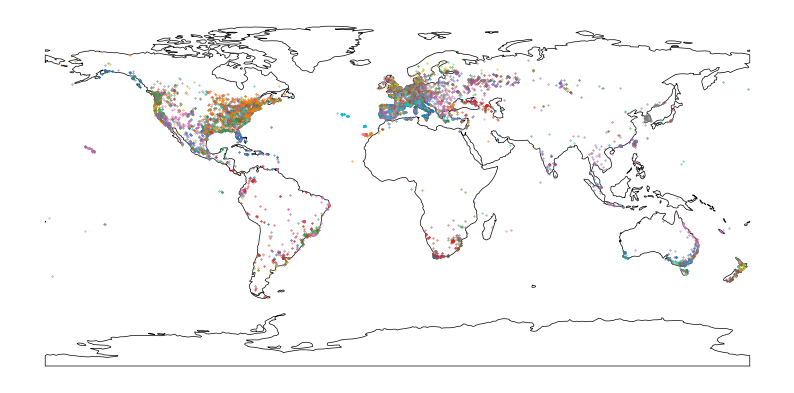

In [18]:
point_list = []
for i in range(len(common)):
    lat = common[i]['decimalLatitude']
    lon = common[i]['decimalLongitude']
    species = common[i]['scientificName']
    
    if lat is None or lon is None:
        none_count += 1
    else:
        point_list.append((lat, lon, species))

df = pd.DataFrame(point_list, columns=["latitude", "longitude", "species"])

geometry = [Point(xy) for xy in zip(df["longitude"], df["latitude"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)

world = gpd.read_file(geodatasets.data.naturalearth.land['url'])

ax = world.plot(figsize=(10, 6), color="white", edgecolor="black", linewidth=0.5)

# plot each species separately
for species, subset in gdf.groupby("species"):
    subset.plot(ax=ax, marker='.', markersize=0.5)

#world
ax.set_axis_off()
plt.show()



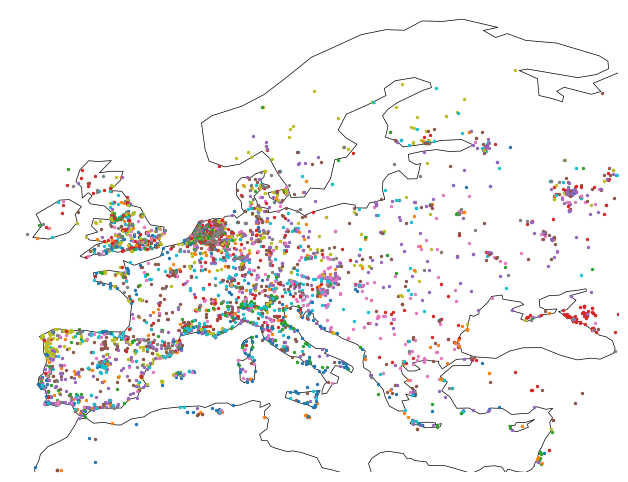

In [19]:
#europe
fig, ax = plt.subplots(figsize=(10, 6))
world.plot(ax=ax, color="white", edgecolor="black", linewidth=0.5)

# plot each species separately
for species, subset in gdf.groupby("species"):
    subset.plot(ax=ax, marker='o', markersize=2)
    
ax.set_xlim(-12, 42)
ax.set_ylim(31, 72)

ax.set_axis_off()
plt.show()


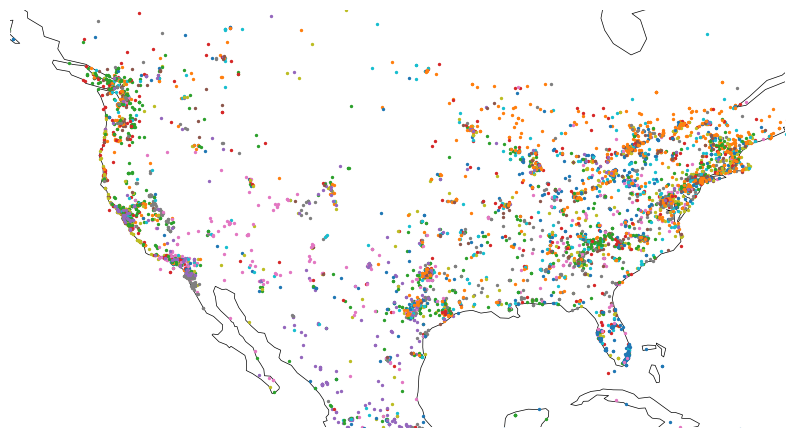

In [20]:
#usa
fig, ax = plt.subplots(figsize=(10, 6))
world.plot(ax=ax, color="white", edgecolor="black", linewidth=0.5)

# plot each species separately
for species, subset in gdf.groupby("species"):
    subset.plot(ax=ax, marker='o', markersize=2)
    
ax.set_xlim(-132, -67)
ax.set_ylim(20, 55)

ax.set_axis_off()
plt.show()

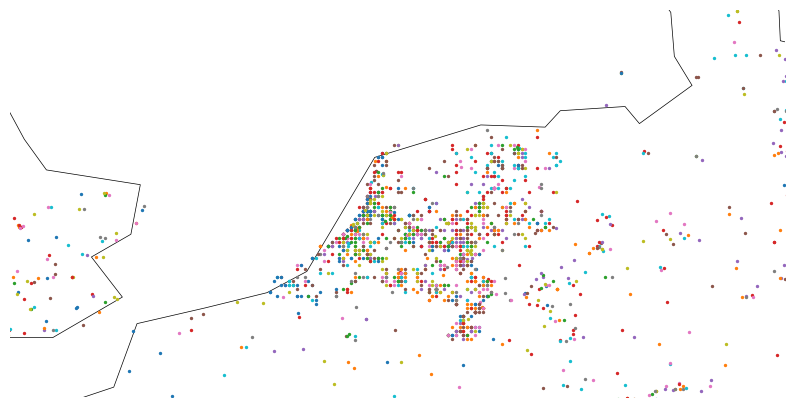

In [21]:
#nl
fig, ax = plt.subplots(figsize=(10, 6))
world.plot(ax=ax, color="white", edgecolor="black", linewidth=0.5)

# plot each species separately
for species, subset in gdf.groupby("species"):
    subset.plot(ax=ax, marker='o', markersize=2)
    
ax.set_xlim(0, 10)
ax.set_ylim(50, 55)

ax.set_axis_off()
plt.show()


In [22]:
# inter/intra species distances(spatial) to file
results = []

coords_radians = np.radians(df[["latitude", "longitude"]].values)

dist_matrix = haversine_distances(coords_radians)
dist_matrix = dist_matrix * 6371000/1000  # multiply by Earth radius to get kilometers

species_array = df["species"].values
for i in range(len(df)):
    species = species_array[i]
    
    dists = dist_matrix[i]
    
    # matrix for intra en inter
    intra_mask = (species_array == species)
    inter_mask = (species_array != species)
    intra = dists[intra_mask]
    intra = intra[intra > 0]
    inter = dists[inter_mask]

    results.append({
        "species": species,
        "intra_mean": np.mean(intra),#intra
        "intra_std": np.std(intra),
        "intra_min": np.min(intra),
        "intra_max": np.max(intra), 
        "inter_mean": np.mean(inter),#inter
        "inter_std": np.std(inter),
        "inter_min": np.min(inter),
        "inter_max": np.max(inter)
    })


#by species
species_stats = pd.DataFrame(results).groupby("species").agg({
    "intra_mean": "mean",
    "intra_std": "mean",
    "intra_min": "mean",
    "intra_max": "mean", 
    "inter_mean": "mean",
    "inter_std": "mean",
    "inter_min": "mean",
    "inter_max": "mean"
}).reset_index()

species_stats.to_json(out_dir+"species_distance.json", indent=1, orient="records")


In [23]:
# inter/intra species distances(spatial) statistics

print('intra species mean')
print(species_stats.sort_values("intra_mean", ascending=False).tail(5))
print('\ninter species mean')
print(species_stats.sort_values("inter_mean", ascending=False).head(5))
print('\nintra species mean mean')
print(species_stats['intra_mean'].mean())
print('\ninter species mean mean')
print(species_stats['inter_mean'].mean())
print('diference between intra and inter')
print(species_stats['inter_mean'].mean()-species_stats['intra_mean'].mean())


intra species mean
                         species  intra_mean  intra_std  intra_min  \
118             Podarcis bocagei  123.845368  70.072397   9.319626   
76    Helminthoglypta tudiculata   92.205624  58.376836   5.803688   
147       Xerarionta stearnsiana   72.325994  50.044509   8.066063   
75   Helminthoglypta nickliniana   63.740988  35.821242   5.230171   
66              Gallotia galloti   39.797888  27.796401   2.194728   

      intra_max   inter_mean    inter_std  inter_min     inter_max  
118  286.445685  6092.110464  4586.925821  11.418053  19930.564940  
76   293.657966  6739.644234  4191.360721   3.610192  18472.681057  
147  295.059118  6771.781747  4195.432636  10.666959  18565.494035  
75   166.955399  6753.679850  4105.654732   3.086876  18192.056355  
66   147.462967  6694.253009  4160.741792  11.833727  19235.632422  

inter species mean
                    species   intra_mean    intra_std  intra_min    intra_max  \
105    Oligosoma polychroma   284.014845   21

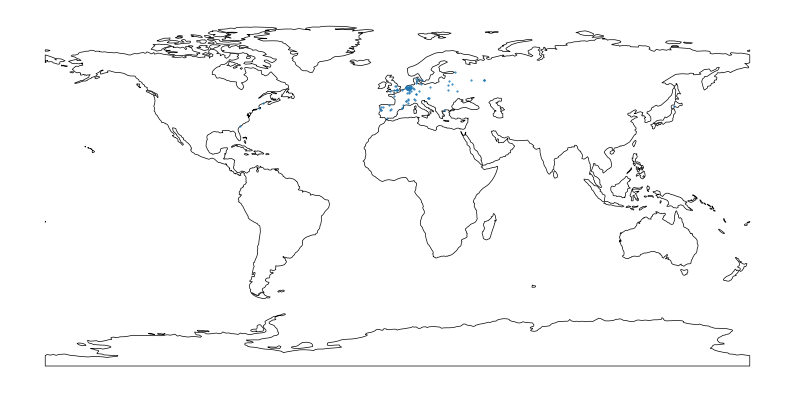

In [24]:
#get plot of specific species
geometry = [Point(xy) for xy in zip(df["longitude"], df["latitude"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)

world = gpd.read_file(geodatasets.data.naturalearth.land['url'])

ax = world.plot(figsize=(10, 6), color="white", edgecolor="black", linewidth=0.5)

# plot each species separately
for species, subset in gdf.groupby("species"):
    if species == "Amanita citrina":
        subset.plot(ax=ax, marker='.', markersize=1)

#world
ax.set_axis_off()
plt.show()

